# Phase 1: dataset setup and propagation-tree exploration

This notebook prepares the raw propagation datasets for the first phase of the InfoGuard project. It loads the project-wide paths and dataset settings from `config.py`, checks that Twitter15, Twitter16, WICO Text, and WICO Graph are available, and normalizes their metadata into a common cascade catalog.

The work carried out here is:

1. Load central configuration and create the configured project directories.
2. Inspect Twitter15 and Twitter16 labels, source tweets, and propagation-tree files.
3. Load WICO Text as the source of tweet/status text and labels.
4. Load WICO Graph as the source of graph edges and cascade structure.
5. Join WICO Text and WICO Graph by normalized tweet/content identifiers while keeping unmatched graph cascades visible.
6. Parse each propagation tree into a directed graph with root, edge, depth, width, cascade-size, and branching-ratio statistics.
7. Save reusable Phase 1 artifacts under the configured evaluation directory for visualization and later modeling.

The paper motivates this workflow by treating misinformation control as a propagation-structure problem: true and false content can spread differently through social networks, so cascade structure is useful beyond text-only classification.


In [1]:
from pathlib import Path
from collections import Counter, defaultdict, deque
import json
import math
import os
import re
import random
import sys

import numpy as np
import pandas as pd
import networkx as nx

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

# Import the central project configuration. The notebook should be launched from
# the project root, where config.py lives. The /mnt/data fallback is useful when
# running this notebook inside the ChatGPT sandbox.
for candidate in [Path.cwd(), Path.cwd().parent, Path('/mnt/data')]:
    if (candidate / 'config.py').exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

try:
    from config import cfg, ROOT as CONFIG_ROOT
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'Could not import config.py. Place config.py in the project root or start Jupyter from the project root.'
    ) from exc

RANDOM_SEED = cfg.seed
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path(CONFIG_ROOT).resolve()
EVAL_DIR = cfg.paths.evaluation
EVAL_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_colwidth', 160)
print(f'Project root: {PROJECT_ROOT}')
print(f'Evaluation directory: {EVAL_DIR}')


Project root: /home/krmsh1n5/Desktop/UFAZ/infoshield
Evaluation directory: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation


## 1. Load paths from `config.py`

All dataset and output paths come from the central configuration object. This keeps both notebooks consistent with the rest of the project and avoids hard-coded local paths.


In [2]:
cfg.paths.make_all()

TWITTER15_DIR = cfg.paths.twitter15
TWITTER16_DIR = cfg.paths.twitter16
WICO_GRAPH_DIR = cfg.paths.wico_graph
WICO_TEXT_DIR = cfg.paths.wico_text

CONFIGURED_PATHS = {
    'Twitter15': TWITTER15_DIR,
    'Twitter16': TWITTER16_DIR,
    'WICO Text': WICO_TEXT_DIR,
    'WICO Graph': WICO_GRAPH_DIR,
    'Processed graphs': cfg.paths.graphs_pt,
    'SBM matrices': cfg.paths.sbm_matrices,
    'Evaluation': EVAL_DIR,
}

path_rows = []
for name, path in CONFIGURED_PATHS.items():
    path = Path(path)
    path_rows.append({
        'name': name,
        'path': str(path),
        'exists': path.exists(),
        'is_dir': path.is_dir(),
    })

paths_df = pd.DataFrame(path_rows)
display(paths_df)

missing_inputs = [
    name for name, path in {
        'Twitter15': TWITTER15_DIR,
        'Twitter16': TWITTER16_DIR,
        'WICO Text': WICO_TEXT_DIR,
        'WICO Graph': WICO_GRAPH_DIR,
    }.items()
    if not Path(path).exists()
]

if missing_inputs:
    print('Missing configured dataset directories:', ', '.join(missing_inputs))
    print('Update config.py or download the missing datasets before running the full notebook.')


✓ All project directories created.


,name,path,exists,is_dir
0,Twitter15,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15,True,True
1,Twitter16,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter16,True,True
2,WICO Text,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text,True,True
3,WICO Graph,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph,True,True
4,Processed graphs,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/processed/graphs,True,True
5,SBM matrices,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/processed/sbm_matrices,True,True
6,Evaluation,/home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation,True,True


## 2. General parsing helpers

The datasets use different formats. These helpers normalize labels and parse edge files defensively.

In [3]:
TRUE_LABELS = {
    'true', 'non-rumor', 'nonrumor', 'non_rumor', 'real', 'non-conspiracy', 'non conspiracy',
    'nonconspiracy', 'not conspiracy', 'credible'
}
FALSE_LABELS = {
    'false', 'rumor', 'fake', '5g-corona conspiracy', '5g corona conspiracy', 'other conspiracy',
    'conspiracy', 'misinformation', 'disinformation'
}

def normalize_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {'nan', 'none', 'null'}:
        return None
    if re.fullmatch(r'\d+\.0', s):
        s = s[:-2]
    return s


def normalize_label(label):
    if label is None or pd.isna(label):
        return 'unknown'
    s = str(label).strip().lower().replace('_', ' ').replace('-', ' ')
    s = re.sub(r'\s+', ' ', s)
    if s in {x.replace('_', ' ').replace('-', ' ') for x in TRUE_LABELS}:
        return 'true'
    if s in {x.replace('_', ' ').replace('-', ' ') for x in FALSE_LABELS}:
        return 'false'
    if 'non' in s and ('rumor' in s or 'conspiracy' in s):
        return 'true'
    if any(k in s for k in ['false', 'fake', 'rumor', 'conspiracy', 'misinformation', 'disinformation']):
        return 'false'
    if any(k in s for k in ['true', 'real', 'credible']):
        return 'true'
    return 'unknown'


def parse_edge_line(line):
    """Parse one edge line from a Twitter15/16 tree file.

    Expected format (from config):
        ['parent_uid', 'parent_tweet_id', 'delay_min']->['child_uid', 'child_tweet_id', 'delay_min']

    Root sentinel example:
        ['ROOT', 'ROOT', '0.0']->['972651', '80080680482123777', '0.0']

    Returns (parent_uid, child_uid, delay_float) or None.
    """
    raw = line.strip()
    if not raw or '->' not in raw:
        return None
    # Split on '->' to get the two bracket-enclosed tuples.
    halves = raw.split('->', 1)
    if len(halves) != 2:
        return None
    # Extract all single-quoted tokens from each half.
    def extract_fields(s):
        return re.findall(r"'([^']*?)'", s)
    parent_fields = extract_fields(halves[0])
    child_fields  = extract_fields(halves[1])
    # Each tuple is [uid, tweet_id, delay]; we need uid (index 0) and delay (index 2).
    if len(parent_fields) < 1 or len(child_fields) < 1:
        return None
    parent_uid = normalize_id(parent_fields[0])
    child_uid  = normalize_id(child_fields[0])
    delay = None
    if len(child_fields) >= 3:
        try:
            delay = float(child_fields[2])
        except ValueError:
            pass
    return parent_uid, child_uid, delay


def graph_from_edges(edge_rows, root_id=None):
    """Build a DiGraph from (parent_uid, child_uid, delay) tuples.

    Root-sentinel rows (parent_uid == cfg.twitter15.root_sentinel) are
    re-rooted to root_id so the source tweet becomes node 0 of the tree.
    Both Twitter datasets share the same sentinel value.
    """
    ROOT_SENTINEL = cfg.twitter15.root_sentinel  # 'ROOT'
    G = nx.DiGraph()
    root_id = normalize_id(root_id)
    for parent, child, delay in edge_rows:
        parent = normalize_id(parent)
        child  = normalize_id(child)
        if parent is None or child is None:
            continue
        if parent.upper() == ROOT_SENTINEL.upper() and root_id:
            parent = root_id
        G.add_edge(parent, child)
        if delay is not None:
            G.nodes[child]['delay'] = delay
    if root_id:
        G.add_node(root_id)
    return G


def find_roots(G):
    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    return roots or list(G.nodes)[:1]


def tree_stats(G, root_id=None):
    root_id = normalize_id(root_id)
    if root_id not in G and G.number_of_nodes() > 0:
        root_id = find_roots(G)[0]
    depths = {}
    if root_id in G:
        try:
            depths = nx.single_source_shortest_path_length(G, root_id)
        except Exception:
            depths = {}
    depth_counts = Counter(depths.values())
    cascade_size = G.number_of_nodes()
    max_depth = max(depth_counts.keys()) if depth_counts else 0
    max_width = max(depth_counts.values()) if depth_counts else cascade_size
    delays = [v.get('delay') for _, v in G.nodes(data=True) if v.get('delay') is not None]
    temporal_span = max(delays) - min(delays) if len(delays) >= 2 else float('nan')
    branching_ratio = G.number_of_edges() / max(1, cascade_size)
    return {
        'num_nodes': cascade_size,
        'num_edges': G.number_of_edges(),
        'cascade_size': cascade_size,
        'max_depth': max_depth,
        'max_width': max_width,
        'branching_ratio': branching_ratio,
        'num_roots': len(find_roots(G)),
        'is_arborescence': nx.is_arborescence(G) if G.number_of_nodes() > 0 else False,
        'temporal_span': temporal_span,
    }


## 3. Load Twitter15 and Twitter16

These datasets typically include root tweet text, labels, and one propagation-tree file per root tweet.

In [4]:
def load_twitter_labels(dataset_dir):
    """Read label.txt: one 'label:tweet_id' line per source tweet."""
    dataset_dir = Path(dataset_dir)
    label_file = dataset_dir / cfg.twitter15.label_file
    rows = []
    if label_file.exists():
        for line in label_file.read_text(errors='ignore').splitlines():
            line = line.strip()
            if not line or ':' not in line:
                continue
            label, tweet_id = line.split(':', 1)
            rows.append({
                'tweet_id': normalize_id(tweet_id),
                'raw_label': label.strip(),
                'label': normalize_label(label.strip()),
            })
    return pd.DataFrame(rows).drop_duplicates('tweet_id') if rows else pd.DataFrame(columns=['tweet_id', 'raw_label', 'label'])


def load_twitter_source_tweets(dataset_dir):
    """Read source_tweets.txt: one 'tweet_id\ttext' line per source tweet."""
    dataset_dir = Path(dataset_dir)
    source_file = dataset_dir / cfg.twitter15.source_tweets_file
    rows = []
    if source_file.exists():
        for line in source_file.read_text(errors='ignore').splitlines():
            line = line.strip()
            if not line or '\t' not in line:
                continue
            tweet_id, text = line.split('\t', 1)
            rows.append({'tweet_id': normalize_id(tweet_id), 'text': text})
    return pd.DataFrame(rows).drop_duplicates('tweet_id') if rows else pd.DataFrame(columns=['tweet_id', 'text'])


def find_tree_files(dataset_dir, trees_subdir):
    """Return all .txt files inside the configured tree sub-directory.

    trees_subdir is cfg.paths.twitter15_trees or cfg.paths.twitter16_trees,
    which already point to <dataset_dir>/tree/.
    """
    trees_path = Path(trees_subdir)
    if not trees_path.exists():
        return []
    skip = {cfg.twitter15.label_file, cfg.twitter15.source_tweets_file}
    return sorted(p for p in trees_path.glob('*.txt') if p.name not in skip)


def load_twitter_tree(path, root_id=None):
    """Parse a single tree file and return a DiGraph.

    The file stem is the source tweet ID when root_id is not provided.
    """
    rows = []
    for line in Path(path).read_text(errors='ignore').splitlines():
        parsed = parse_edge_line(line)
        if parsed:
            rows.append(parsed)
    if root_id is None:
        root_id = Path(path).stem
    return graph_from_edges(rows, root_id=root_id)


def load_twitter_dataset(name, dataset_dir, trees_subdir):
    if dataset_dir is None or not Path(dataset_dir).exists():
        print(f'{name}: dataset directory not found.')
        return pd.DataFrame(), {}
    labels = load_twitter_labels(dataset_dir)
    texts  = load_twitter_source_tweets(dataset_dir)
    meta   = labels.merge(texts, on='tweet_id', how='outer')
    meta['dataset'] = name
    tree_files = find_tree_files(dataset_dir, trees_subdir)
    graphs = {}
    for path in tree_files:
        root_id = normalize_id(path.stem)
        G = load_twitter_tree(path, root_id=root_id)
        n, e = G.number_of_nodes(), G.number_of_edges()
        if cfg.twitter15.min_tree_size <= n <= cfg.twitter15.max_tree_size:
            graphs[root_id] = {'graph': G, 'path': str(path), 'root_id': root_id}
    print(f'{name}: {len(meta)} label/text rows, {len(graphs)} trees '
          f'(size filter {cfg.twitter15.min_tree_size}–{cfg.twitter15.max_tree_size})')
    return meta, graphs

twitter15_meta, twitter15_graphs = load_twitter_dataset(
    'Twitter15', TWITTER15_DIR, cfg.paths.twitter15_trees
)
twitter16_meta, twitter16_graphs = load_twitter_dataset(
    'Twitter16', TWITTER16_DIR, cfg.paths.twitter16_trees
)

display(pd.concat([twitter15_meta.head(), twitter16_meta.head()], ignore_index=True))


Twitter15: 1490 label/text rows, 1463 trees (size filter 3–2000)
Twitter16: 818 label/text rows, 800 trees (size filter 3–2000)


,tweet_id,raw_label,label,text,dataset
0,265953285247209472,false,false,deep-fried left wings demo-crab cakes barack-amole & chips malia quesadillas hawaiian pizza sloppy joe bidens obamacare-rot cake,Twitter15
1,273182568298450945,false,false,42 million dead in bloodiest black friday weekend on record URL,Twitter15
2,273278761909239808,false,false,42 million dead in bloodiest black friday weekend on record URL,Twitter15
3,295152287901417472,true,true,#prayforchristopher 5k run .. well we are walking lol @savannahn_2012 @lemongella URL,Twitter15
4,295944137948151809,false,false,a photo of black nurses saving the life of a kkk member. URL,Twitter15
5,498430783699554305,true,true,witness: police allegedly stopped mike brown after yelling at him to walk on sidewalk. #ferguson URL,Twitter16
6,500378223977721856,true,true,"oh. so now the #ferguson police chief says the cop didn't know about the robbery when he stopped #mikebrown. the kid was ""jaywalking""? bs!",Twitter16
7,524922729485848576,true,true,only photo i will tweet. cpr being performed on the soldier now. i heard four shots. #ottawa URL,Twitter16
8,524923462398513152,true,true,shots fired on parliament hill after a man walked up with a gun. i'm locked in a security office on parliament hill,Twitter16
9,524923676484177920,true,true,breaking - shooting on parliament hill. rcmp have weapons drawn #cdnpoli URL,Twitter16


## 4. Load WICO Text separately

WICO Text is used for labels and textual metadata. It may not contain propagation edges.

In [5]:
def load_wico_text_dataset(wico_text_dir):
    """Read WICO Text files.

    Each file listed in cfg.wico.text_files contains one tweet ID (bare integer)
    per line with no header. The label for every ID in a file is determined by
    the dict key (0 = 5g-corona, 1 = other conspiracy, 2 = non-conspiracy).
    """
    if wico_text_dir is None:
        print('WICO Text directory not found.')
        return pd.DataFrame(columns=['content_id', 'tweet_id', 'raw_label', 'label', 'text_path'])
    wico_text_dir = Path(wico_text_dir)
    # Invert label_map so we can look up the human-readable name by int key.
    int_to_name = {v: k for k, v in cfg.wico.label_map.items()}
    rows = []
    for label_int, filename in cfg.wico.text_files.items():
        path = wico_text_dir / filename
        if not path.exists():
            print(f'  Missing WICO Text file: {path}')
            continue
        raw_label = int_to_name.get(label_int, str(label_int))
        norm_label = normalize_label(raw_label)
        for line in path.read_text(errors='ignore').splitlines():
            tweet_id = normalize_id(line.strip())
            if tweet_id is None:
                continue
            rows.append({
                'content_id': tweet_id,
                'tweet_id':   tweet_id,
                'raw_label':  raw_label,
                'label':      norm_label,
                'text_path':  str(path),
            })
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.drop_duplicates('content_id')
    print(f'WICO Text: {len(out)} tweet IDs across {len(cfg.wico.text_files)} files')
    return out

wico_text = load_wico_text_dataset(WICO_TEXT_DIR)
display(wico_text.head())
display(wico_text['label'].value_counts(dropna=False).rename('count').to_frame() if not wico_text.empty else wico_text)


WICO Text: 9688 tweet IDs across 3 files


,content_id,tweet_id,raw_label,label,text_path
0,1037704685652561926,1037704685652561926,5g-corona,unknown,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt
1,1200224860561199104,1200224860561199104,5g-corona,unknown,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt
2,1221197064740143104,1221197064740143104,5g-corona,unknown,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt
3,1221428849881370626,1221428849881370626,5g-corona,unknown,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt
4,1222024051830509568,1222024051830509568,5g-corona,unknown,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt


,count
label,
true,6618
unknown,1892
false,1178


## 5. Load WICO Graph separately

WICO Graph provides propagation structure. The parser below groups graph files by content ID when files are one cascade each. If the graph files contain columns, it tries to infer source, target, and cascade/content ID columns.

In [6]:
def load_wico_graph_cascade(tweet_dir):
    """Load one cascade from a per-tweet WICO Graph directory.

    Directory contains:
      edges.txt  — 'source_id target_id' per line (space-separated ints, no header)
      nodes.csv  — CSV with header: id,time,friends,followers
    """
    tweet_dir = Path(tweet_dir)
    root_id   = normalize_id(tweet_dir.name)

    # Parse edges.txt.
    edges_path = tweet_dir / cfg.wico.graph_edges_file
    G = nx.DiGraph()
    if edges_path.exists():
        for line in edges_path.read_text(errors='ignore').splitlines():
            parts = line.strip().split()
            if len(parts) == 2:
                src, dst = normalize_id(parts[0]), normalize_id(parts[1])
                if src and dst:
                    G.add_edge(src, dst)

    # Attach node features from nodes.csv.
    nodes_path = tweet_dir / cfg.wico.graph_nodes_file
    if nodes_path.exists():
        nodes_df = pd.read_csv(nodes_path, dtype=str)
        nodes_df.columns = [c.strip().lower() for c in nodes_df.columns]
        expected = list(cfg.wico.graph_nodes_columns)  # ['id','time','friends','followers']
        for col in expected:
            if col not in nodes_df.columns:
                nodes_df[col] = None
        for _, row in nodes_df.iterrows():
            nid = normalize_id(row['id'])
            if nid:
                G.add_node(nid)
                for feat in ('time', 'friends', 'followers'):
                    try:
                        G.nodes[nid][feat] = int(row[feat])
                    except (ValueError, KeyError, TypeError):
                        pass

    if root_id:
        G.add_node(root_id)
    return G, root_id


def load_wico_graph_dataset(wico_graph_dir):
    """Walk cfg.wico.graph_dirs and load every per-tweet cascade.

    Directory layout (from config):
        wico-graph/
            5G_Conspiracy_Graphs/   (label 0)
            Other_Graphs/           (label 1)
            Non_Conspiracy_Graphs/  (label 2)
                <tweet_id>/
                    edges.txt
                    nodes.csv
    """
    if wico_graph_dir is None:
        print('WICO Graph directory not found.')
        return {}, pd.DataFrame(columns=['content_id', 'graph_path', 'label_int'])
    wico_graph_dir = Path(wico_graph_dir)
    graphs = {}
    manifest_rows = []
    for label_int, folder_name in cfg.wico.graph_dirs.items():
        class_dir = wico_graph_dir / folder_name
        if not class_dir.exists():
            print(f'  Missing WICO Graph folder: {class_dir}')
            continue
        tweet_dirs = sorted(p for p in class_dir.iterdir() if p.is_dir())
        for tweet_dir in tweet_dirs:
            G, root_id = load_wico_graph_cascade(tweet_dir)
            if G.number_of_nodes() == 0:
                continue
            graphs[root_id] = {'graph': G, 'path': str(tweet_dir), 'root_id': root_id, 'label_int': label_int}
            manifest_rows.append({'content_id': root_id, 'graph_path': str(tweet_dir), 'label_int': label_int})
    print(f'WICO Graph: {len(graphs)} cascades from {len(cfg.wico.graph_dirs)} class folders')
    manifest = pd.DataFrame(manifest_rows).drop_duplicates('content_id') if manifest_rows else pd.DataFrame(columns=['content_id', 'graph_path', 'label_int'])
    return graphs, manifest

wico_graphs, wico_graph_manifest = load_wico_graph_dataset(WICO_GRAPH_DIR)
display(wico_graph_manifest.head())


WICO Graph: 2502 cascades from 3 class folders


,content_id,graph_path,label_int
0,1,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/1,0
1,10,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/10,0
2,100,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/100,0
3,101,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/101,0
4,102,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/102,0


## 6. Join WICO Text and WICO Graph

This is the important rewrite for the two-dataset case. WICO Text and WICO Graph are separate inputs, so the notebook creates a joined metadata table. Cascades without matching text labels are kept with `unknown` labels instead of being discarded.

In [7]:
def build_wico_joined_metadata(wico_text, wico_graph_manifest):
    """Join WICO Graph manifest with WICO Text labels.

    wico_text has columns: content_id, tweet_id, raw_label, label, text_path
    wico_graph_manifest has columns: content_id, graph_path, label_int

    The join key is content_id (tweet ID). Graph cascades with no matching
    text entry are kept with label='unknown'.
    """
    graph_meta = wico_graph_manifest.copy()
    if graph_meta.empty:
        return pd.DataFrame(columns=['dataset','tweet_id','content_id','label','raw_label','graph_path','has_graph','has_text'])
    graph_meta['content_id'] = graph_meta['content_id'].map(normalize_id)

    if wico_text.empty:
        joined = graph_meta.copy()
        joined['tweet_id']  = joined['content_id']
        joined['raw_label'] = None
        joined['label']     = 'unknown'
        joined['has_text']  = False
    else:
        text_meta = wico_text[['content_id', 'tweet_id', 'raw_label', 'label']].copy()
        text_meta['content_id'] = text_meta['content_id'].map(normalize_id)
        joined = graph_meta.merge(text_meta, on='content_id', how='left')
        joined['tweet_id']  = joined['tweet_id'].fillna(joined['content_id'])
        joined['label']     = joined['label'].fillna('unknown')
        # WICO Text contains only tweet IDs — no text content is available.
        joined['has_text']  = False

    joined['dataset']   = 'WICO'
    joined['has_graph'] = True
    return joined[['dataset','tweet_id','content_id','label','raw_label','graph_path','has_graph','has_text']]

wico_meta = build_wico_joined_metadata(wico_text, wico_graph_manifest)
print('Joined WICO rows:', len(wico_meta))
display(wico_meta.head())
display(wico_meta['label'].value_counts(dropna=False).rename('count').to_frame() if not wico_meta.empty else wico_meta)

unmatched = wico_meta[wico_meta['label'].eq('unknown')]
print(f'WICO graph cascades without matched WICO Text label: {len(unmatched)}')


Joined WICO rows: 2502


,dataset,tweet_id,content_id,label,raw_label,graph_path,has_graph,has_text
0,WICO,1,1,unknown,NaN,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/1,True,False
1,WICO,10,10,unknown,NaN,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/10,True,False
2,WICO,100,100,unknown,NaN,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/100,True,False
3,WICO,101,101,unknown,NaN,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/101,True,False
4,WICO,102,102,unknown,NaN,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/102,True,False


,count
label,
unknown,2502


WICO graph cascades without matched WICO Text label: 2502


## 7. Build a unified propagation-tree catalog

The catalog records every cascade that has a graph. It also keeps labels from the appropriate metadata source.

In [8]:
all_graphs = {}
all_meta_parts = []

for dataset_name, meta, graphs in [
    ('Twitter15', twitter15_meta, twitter15_graphs),
    ('Twitter16', twitter16_meta, twitter16_graphs),
]:
    if graphs:
        for root_id, payload in graphs.items():
            all_graphs[(dataset_name, root_id)] = payload
        if not meta.empty:
            tmp = meta.copy()
            tmp['content_id'] = tmp['tweet_id']
            tmp['has_graph']  = tmp['tweet_id'].isin(graphs.keys())
            tmp['has_text']   = tmp['text'].fillna('').astype(str).str.len() > 0 if 'text' in tmp.columns else False
            if 'raw_label' not in tmp.columns:
                tmp['raw_label'] = None
            if 'label' not in tmp.columns:
                tmp['label'] = 'unknown'
            tmp['graph_path'] = tmp['tweet_id'].map(lambda x: graphs.get(normalize_id(x), {}).get('path'))
            # Twitter datasets have source tweet text; keep it in the catalog.
            text_col = tmp['text'] if 'text' in tmp.columns else pd.Series('', index=tmp.index)
            tmp['text'] = text_col.fillna('')
            all_meta_parts.append(tmp[['dataset','tweet_id','content_id','label','raw_label','text','graph_path','has_graph','has_text']])

if wico_graphs:
    for cid, payload in wico_graphs.items():
        all_graphs[('WICO', cid)] = payload
if not wico_meta.empty:
    # WICO has no text column; add an empty one so schemas align.
    wico_meta_aligned = wico_meta.copy()
    wico_meta_aligned['text'] = ''
    all_meta_parts.append(wico_meta_aligned[['dataset','tweet_id','content_id','label','raw_label','text','graph_path','has_graph','has_text']])

all_meta = pd.concat(all_meta_parts, ignore_index=True) if all_meta_parts else pd.DataFrame(
    columns=['dataset','tweet_id','content_id','label','raw_label','text','graph_path','has_graph','has_text']
)
all_meta['tweet_id']   = all_meta['tweet_id'].map(normalize_id)
all_meta['content_id'] = all_meta['content_id'].map(normalize_id)
all_meta['label']      = all_meta['label'].fillna('unknown').map(normalize_label)

print('Total graphs:', len(all_graphs))
print('Total metadata rows:', len(all_meta))
display(all_meta.groupby(['dataset','label']).size().rename('count').reset_index())


Total graphs: 4765
Total metadata rows: 4810


,dataset,label,count
0,Twitter15,false,370
1,Twitter15,true,746
2,Twitter15,unknown,374
3,Twitter16,false,205
4,Twitter16,true,412
5,Twitter16,unknown,201
6,WICO,unknown,2502


## 8. Compute propagation-tree statistics

These features are the Phase 1 bridge from raw files to paper-inspired modeling:

- `cascade_size` approximates final reach.
- `max_depth` captures how many reshare generations exist.
- `max_width` captures burstiness at a depth.
- `branching_ratio` approximates average edge expansion.
- `is_arborescence` checks whether the cascade is a clean tree.

In [9]:
summary_rows = []
meta_lookup = all_meta.set_index(['dataset','content_id']).to_dict('index') if not all_meta.empty else {}
for (dataset, cid), payload in all_graphs.items():
    G = payload['graph']
    stats = tree_stats(G, root_id=payload.get('root_id', cid))
    meta = meta_lookup.get((dataset, cid), {})
    summary_rows.append({
        'dataset': dataset,
        'tweet_id': cid,
        'content_id': cid,
        'label': normalize_label(meta.get('label', 'unknown')),
        'raw_label': meta.get('raw_label'),
        'graph_path': payload.get('path'),
        'text': meta.get('text', ''),
        **stats,
    })

tree_summary = pd.DataFrame(summary_rows)
if not tree_summary.empty:
    tree_summary = tree_summary.sort_values(['dataset','label','cascade_size'], ascending=[True, True, False])

summary_path = EVAL_DIR / 'propagation_tree_summary.csv'
tree_summary.to_csv(summary_path, index=False)
print('Saved:', summary_path)
display(tree_summary.head(20))

display(tree_summary.groupby(['dataset','label'])[['cascade_size','max_depth','max_width','branching_ratio']].describe().round(2) if not tree_summary.empty else tree_summary)

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/propagation_tree_summary.csv


,dataset,tweet_id,content_id,label,raw_label,graph_path,text,num_nodes,num_edges,cascade_size,max_depth,max_width,branching_ratio,num_roots,is_arborescence,temporal_span
4,Twitter15,295944137948151809,295944137948151809,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/295944137948151809.txt,a photo of black nurses saving the life of a kkk member. URL,1992,2001,1992,6,1514,1.004518,1,False,1440124.52
735,Twitter15,537377960471166976,537377960471166976,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/537377960471166976.txt,"y'all, i just read that abc paid darren wilson $500k for the interview. destroying black life remains a lucrative american career. #ferguson",1864,1908,1864,6,1227,1.023605,1,False,24541.17
900,Twitter15,560442390805090307,560442390805090307,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/560442390805090307.txt,drift into a peaceful slumber w/@thejeffbridges' new #sleepingtapes album. listen now at URL #om URL,1749,1782,1749,4,1583,1.018868,1,False,288113.47
169,Twitter15,489794593580650497,489794593580650497,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/489794593580650497.txt,breaking: malaysia airlines passenger 'shot down' near russian border in ukraine URL URL,1687,1693,1687,11,756,1.003557,1,False,6978.48
280,Twitter15,504433135036407808,504433135036407808,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/504433135036407808.txt,gonna be unreal when las vegas goes undefeated at home every year........ #nhl #expansion,1610,1620,1610,4,1498,1.006211,1,False,1031962.12
683,Twitter15,532281981795848192,532281981795848192,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/532281981795848192.txt,manager bans teen slang from work including 'chill'. adds stop accusing people of having ebola URL URL,1597,1610,1597,9,798,1.008140,1,False,400343.07
37,Twitter15,376982539132366848,376982539132366848,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/376982539132366848.txt,j.k. rowling is working on an 8th harry potter book.,1528,1547,1528,4,1437,1.012435,1,False,263646.72
454,Twitter15,521727831307722753,521727831307722753,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/521727831307722753.txt,someone spray painted a penis on a $2.4 mill bugatti URL,1436,1444,1436,5,1119,1.005571,1,False,535535.17
168,Twitter15,489794369487380480,489794369487380480,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/489794369487380480.txt,breaking: malaysian airlines passenger 'shot down' near russian border in ukraine URL URL,1389,1390,1389,7,1145,1.000720,1,False,4300.77
657,Twitter15,531607884220485632,531607884220485632,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/531607884220485632.txt,apec photo of the day. rt @marc_leibowitz: photo of vladimir putin's motorcade. posted without comment. URL,1375,1408,1375,10,442,1.024000,1,False,630015.13


cascade_size                                               \
                         count    mean     std   min     25%    50%     75%   
dataset   label                                                               
Twitter15 false          365.0  325.92  321.29  98.0  144.00  205.0  356.00   
          true           728.0  436.26  329.45  89.0  195.25  352.0  554.00   
          unknown        370.0  262.23  256.59  57.0  128.00  166.5  276.00   
Twitter16 false          198.0  294.63  266.05  75.0  137.00  212.0  332.75   
          true           405.0  469.37  355.74  91.0  214.00  338.0  660.00   
          unknown        197.0  281.39  303.12  95.0  131.00  167.0  293.00   
WICO      unknown       2502.0   63.81   34.71   4.0   26.00   85.0   93.00   

                          max_depth        ... max_width          \
                      max     count  mean  ...       75%     max   
dataset   label                            ...                     
Twitter15 false    1992.0     365.0  4.58  ...    271.00  1583.0   
          true     1988.0     728.0  4.59  ...    447.25  1771.0   
          unknown  1972.0     370.0  4.64  ...    216.00  1268.0   
Twitter16 false    1597.0     198.0  4.74  ...    267.00  1199.0   
          true     1950.0     405.0  4.85  ...    501.00  1465.0   
          unknown  1972.0     197.0  4.42  ...    225.00  1268.0   
WICO      unknown   102.0    2502.0  0.00  ...      1.00     1.0   

                  branching_ratio                                             
                            count  mean   std   min   25%   50%   75%    max  
dataset   label                                                               
Twitter15 false             365.0  1.01  0.03  0.99  1.00  1.01  1.02   1.43  
          true              728.0  1.01  0.02  0.99  1.00  1.00  1.01   1.17  
          unknown           370.0  1.01  0.02  0.98  1.00  1.01  1.02   1.14  
Twitter16 false             198.0  1.01  0.03  0.99  1.00  1.00  1.02   1.17  
          true              405.0  1.01  0.02  0.99  1.00  1.00  1.01   1.11  
          unknown           197.0  1.02  0.02  0.99  1.00  1.01  1.03   1.11  
WICO      unknown          2502.0  1.94  2.76  0.00  0.79  1.21  2.15  49.35  

[7 rows x 32 columns]

## 9. Select 3 to 5 example trees for visualization

The visualization notebook will use these examples. Selection prefers labeled true and false cascades with non-trivial structure.

In [10]:
def select_examples(df, per_label=3, max_total=10):
    if df.empty:
        return df
    candidates = df[df['num_edges'] > 0].copy()
    if candidates.empty:
        candidates = df.copy()
    selected = []
    for label in ['true', 'false']:
        part = candidates[candidates['label'].eq(label)].sort_values(['cascade_size','max_depth'], ascending=False)
        selected.append(part.head(per_label))
    out = pd.concat(selected, ignore_index=True) if selected else pd.DataFrame()
    if len(out) == 0:
        out = candidates.sort_values(['cascade_size','max_depth'], ascending=False).head(max_total)
    return out.head(max_total)

sample_trees = select_examples(tree_summary, per_label=3, max_total=10)
samples_path = EVAL_DIR / 'sample_tree_ids.csv'
sample_trees.to_csv(samples_path, index=False)
print('Saved:', samples_path)
display(sample_trees[['dataset','tweet_id','label','cascade_size','max_depth','max_width','graph_path']])

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/sample_tree_ids.csv


,dataset,tweet_id,label,cascade_size,max_depth,max_width,graph_path
0,Twitter15,693925198630821889,true,1988,4,1771,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/693925198630821889.txt
1,Twitter15,764505291853627392,true,1955,5,1552,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/764505291853627392.txt
2,Twitter16,674263945172119552,true,1950,8,1233,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter16/tree/674263945172119552.txt
3,Twitter15,295944137948151809,false,1992,6,1514,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/295944137948151809.txt
4,Twitter15,537377960471166976,false,1864,6,1227,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/537377960471166976.txt
5,Twitter15,560442390805090307,false,1749,4,1583,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/560442390805090307.txt


## 10. Optional: quick sanity plot

This is not the final visualization. It is a quick check that the summary file looks reasonable.

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/quick_cascade_size_boxplot.png


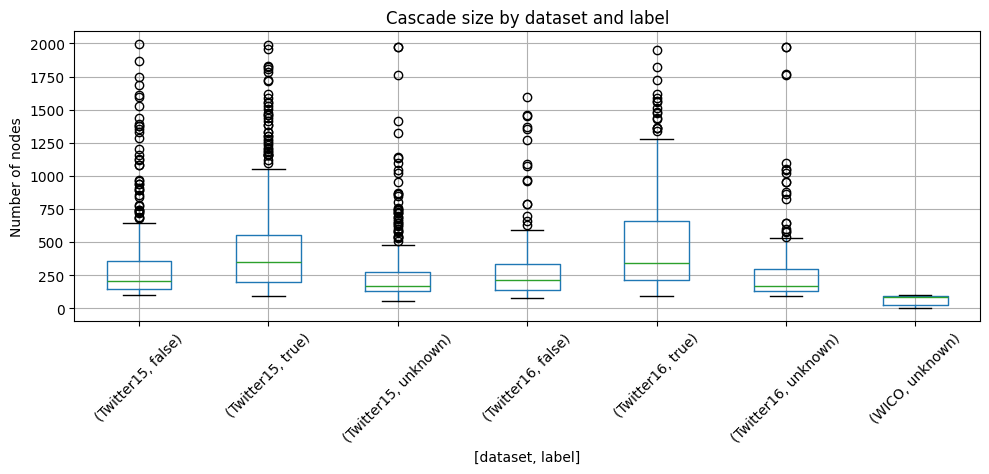

In [11]:
if plt is not None and not tree_summary.empty:
    ax = tree_summary.boxplot(column='cascade_size', by=['dataset','label'], rot=45, figsize=(10, 5))
    ax.set_title('Cascade size by dataset and label')
    ax.set_ylabel('Number of nodes')
    plt.suptitle('')
    plt.tight_layout()
    out = EVAL_DIR / 'quick_cascade_size_boxplot.png'
    plt.savefig(out, dpi=160)
    print('Saved:', out)
    plt.show()
else:
    print('No plot created.')